## **Machine Learning Aplicado a las Finanzas** 🚀
### **Sesión 3: Validación en Series Temporales — Walk-Forward & OOT**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

---

## 🍁 **`Recap Split Data`**

Al momento de construir modelos de machine learning (aprendizaje supervisado o no supervisado), es necesario generar una partición de datos en conjuntos de `train`, `test` y en algunos casos, utilizan un tercer conjunto llamado `validation`. No obstante, para efectos de este curso, utilizaremos particiones  `train` y  `test` en proporciones de 70% y 30% (salvo que se diga lo contrario)

<tr>
<td><img src="../figs/figura_007.png" align="middle" style="width: 1000px;"/> </td>
</tr>

La idea principal detrás de este mecanismo, es que simula cómo se comportará el modelo con datos que nunca ha visto, lo que ayuda en gran medida a evitar el problema de sobre ajuste u **`overfitting`**.  El concepto de `overfitting` significa que el modelo aprende patrones específicos del conjunto de entrenamiento en lugar de generalizar. En otras palabras, el modelo aprende de memoria patrones específicos de los datos y al momento de someterlo con un conjunto de datos diferentes, no es capaz de reconocerlos. 

Ahora, cuando los datos son escasos, en lugar de generar un split fijo, se divide el conjunto de `train` en $K$ folds, esto es conocido como `cross-validation` y consiste en entrenar el modelo en $k$ particiones de datos con el objetivo de reducir la varianza en la estimacion del error.

<tr>
<td><img src="../figs/figura_008.png" align="middle" style="width: 1000px;"/> </td>
</tr>

## 🍁 **`Recap Time Series`**

Una serie de tiempo puede definirse como un `proceso estocástico` que genera una `secuencia de variables aleatorias indexadas en el tiempo`. En este contexto, una serie de tiempo es un conjunto de observaciones aleatorias que se recolectan secuencialmente a lo largo de un intervalo temporal. Formalmente, un proceso estocástico $\{X_t\}$ se define como una colección de variables aleatorias indexadas en el tiempo $t$, donde $t$ es un conjunto discreto.  

Algunas propiedades de las series de tiempo:

1. **`Dependencia Temporal`**: Las observaciones en una serie de tiempo no son independientes entre sí. Existe una relación o dependencia entre las observaciones en diferentes momentos de tiempo. Esta dependencia puede ser de corta o larga duración y se analiza mediante `funciones de autocorrelación`.

2. **`Estacionariedad`**: Un proceso estocástico puede ser estacionario si sus propiedades estadísticas no cambian con el tiempo. Para una serie de tiempo, esto significa que la media, la varianza y la autocorrelación son constantes a lo largo del tiempo. Hay diferentes tipos de estacionariedad, como la estacionariedad fuerte y la estacionariedad débil.

3. **`Estructura de Ruido`**: Las series de tiempo suelen incluir un componente de ruido o error que es aleatorio y no predecible. Este ruido puede seguir una distribución específica (como la normal) y puede influir en la variabilidad de las observaciones.

4. **`Modelos Específicos`**: Existen varios modelos para describir y analizar procesos estocásticos en series de tiempo, como el modelo autoregresivo (AR), el modelo de media móvil (MA), y el modelo ARIMA mencionado anteriormente. Estos modelos permiten capturar la estructura de dependencia en los datos.

#### Ejemplo 1. Retornos vs volatilidad

Imaginemos que estamos mirando el mercado, en particular estamos mirando los valores de cierre del `SPY500` en donde vemos que el dia lunes y martes estuvo tranquilo, mientras que el miercoles, jueves y vienres hubo volatilidad. Aun si el retorno (sube/baja) de un día a otro parece aleatorio, la volatilidad suele venir en rachas: cuando empieza un periodo volátil, suele durar varios días (esto, es uno de los hechos estilizados de las series financieras vista en el curso de Data Science para las Finanzas). Esto significa que 

* La variable `volatilidad` de hoy se parece bastante a la de ayer
* Las features típicas (|retorno|, retorno $^2$, volatilidad rolling) cargan esa memoria

In [1]:
import yfinance as yf
import pandas as pd

# Descarga de series de precios de SPY
df = yf.download("SPY", start = "2015-01-01", progress = False)

#  Tomar una columna de precios (Series) de forma robusta
if "Adj Close" in df.columns:
    px = df["Adj Close"]
elif "Close" in df.columns:
    px = df["Close"]
else:
    # por si viene MultiIndex raro, toma la primera columna numérica
    px = df.select_dtypes("number").iloc[:, 0]

# Forzar Series 1D si aún viene como DataFrame de 1 columna
if isinstance(px, pd.DataFrame):
    px = px.iloc[:, 0]

r = px.pct_change().dropna()

ac_ret = r.autocorr(lag = 1)  # (retorno)
ac_abs = r.abs().autocorr(lag = 1) # (magnitud, proxy de volatilidad)
ac_sq  = (r**2).autocorr(lag = 1)  # (otra proxy de volatilidad)
 
print(f"ACF lag1 return: {ac_ret:.4f}")
print(f"ACF lag1 |return|: {ac_abs:.4f}")
print(f"ACF lag1 return^2: {ac_sq:.4f}")

ACF lag1 return: -0.1192
ACF lag1 |return|: 0.3534
ACF lag1 return^2: 0.4201


**Observacion 🖍️** Si se hace split aleatorio, el modelo puede entrenar con días volátiles del futuro y testear con días volátiles del pasado mezclados; como son parecidos, parece que generaliza, pero en realidad se está usando la misma racha partida en dos.

#### Ejemplo 2. Alineacion Temporal

En series de tiempo, existen dos relojes:

* La decisión: en $t$ solo conoces información hasta $t$.
  
* El outcome: el label suele ser algo que ocurre en $t+h$ (p. ej. retorno mañana). Si no se alinea bien (shift), terminas metiendo información del futuro en el dataset sin darte cuenta. Esto es conocido como leakage.

Supongamos que queremos clasificar si mañana el retorno será positivo:

In [2]:
df = pd.DataFrame({"r": r})
df["y_next"] = (df["r"].shift(-1) > 0).astype(int)   # label en t usa retorno futuro t+1 (mueves el retorno futuro hacia la fila de hoy)
df["feat_lag1"] = df["r"].shift(1)                   # feature usa pasado
df["feat_vol20"] = df["r"].rolling(20).std()         # rolling usa pasado (incluye t)

print(df[["r","feat_lag1","feat_vol20","y_next"]].head(25))

                   r  feat_lag1  feat_vol20  y_next
Date                                               
2015-01-05 -0.018059        NaN         NaN       0
2015-01-06 -0.009419  -0.018059         NaN       1
2015-01-07  0.012461  -0.009419         NaN       1
2015-01-08  0.017745   0.012461         NaN       0
2015-01-09 -0.008014   0.017745         NaN       0
2015-01-12 -0.007834  -0.008014         NaN       0
2015-01-13 -0.002813  -0.007834         NaN       0
2015-01-14 -0.006037  -0.002813         NaN       0
2015-01-15 -0.009160  -0.006037         NaN       1
2015-01-16  0.013114  -0.009160         NaN       1
2015-01-20  0.002133   0.013114         NaN       1
2015-01-21  0.005048   0.002133         NaN       1
2015-01-22  0.014871   0.005048         NaN       0
2015-01-23 -0.005483   0.014871         NaN       1
2015-01-26  0.002342  -0.005483         NaN       0
2015-01-27 -0.013191   0.002342         NaN       0
2015-01-28 -0.012824  -0.013191         NaN       1
2015-01-29  

**Observacion 🖍️** Si alineas mal, incluso con split temporal puedes “ganar” injustamente. Pero cuando haces split temporal y defines “punto de decisión”, te obligas a verificar alineación: “¿en esta fila, qué sabía yo en ese momento?”. Es la disciplina que evita errores.

#### Ejemplo 3. Split aleatorio vs Split temporal

En datos temporales, un split aleatorio mezcla periodos. En finanzas eso es peligroso por dos motivos:

* Drift/regímenes: 2017 no se parece a 2020; mezclarlos en train y test hace que el test no sea realmente futuro.
  
* Dependencia temporal: puntos cercanos en el tiempo son similares. Al mezclar, terminas con observaciones muy parecidas en train y test (contaminación).

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X = df[["feat_lag1","feat_vol20"]].dropna()
y = df.loc[X.index, "y_next"].dropna()
X, y = X.align(y, join="inner", axis=0)

# Split aleatorio (NO recomendado)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=42)
m = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
auc_random = roc_auc_score(yte, m.predict_proba(Xte)[:,1])

# Split temporal (OOT)
cut = int(len(X)*0.7)
Xtr2, Xte2 = X.iloc[:cut], X.iloc[cut:]
ytr2, yte2 = y.iloc[:cut], y.iloc[cut:]
m2 = LogisticRegression(max_iter=2000).fit(Xtr2, ytr2)
auc_time = roc_auc_score(yte2, m2.predict_proba(Xte2)[:,1])

print(f"AUC split aleatorio: {auc_random:.3f}")
print(f"AUC split temporal OOT: {auc_time:.3f}")

AUC split aleatorio: 0.489
AUC split temporal OOT: 0.533


**Observacion 🖍️** El objetivo en finanzas no es *interpolar* entre puntos similares; es generalizar hacia un futuro con drift. El split temporal es el único que respeta la causalidad y el flujo de información. Además permite ver estabilidad por bloques (walk-forward), que es clave para decidir si algo vale la pena.

### 🎖️ **`Objetivos de la clase`**

Al finalizar esta clase el estudiante podrá:

1. Identificar y evitar las formas más comunes de **data leakage temporal** en finanzas
2. Distinguir entre In-Sample, Out-of-Sample y Out-of-Time
3. Implementar **Walk-Forward Validation** con expanding y rolling window desde cero
4. Construir pipelines anti-leakage usando `sklearn.Pipeline` con splits temporales correctos
5. Reportar métricas fold-by-fold y evaluar **estabilidad temporal** del modelo
6. Aplicar **Nested CV temporal** para tuning de hiperparámetros sin contaminar el test
7. Comparar modelos contra baselines financieramente relevantes


##  📚 **`Diccionario`**

Algunos conceptos que estaremos usando recurrentemente durante el curso.

| Término | Definición formal | Implicación práctica |
|---------|-------------------|---------------------|
| **In-sample (IS)** | Datos usados para estimar parámetros del modelo | Si el modelo solo es bueno IS, hay overfitting |
| **Out-of-sample (OOS)** | Datos no vistos durante el entrenamiento | El estándar mínimo de evaluación |
| **Out-of-time (OOT)** | OOS que además pertenece a un **periodo futuro** | El estándar correcto en finanzas |
| **Horizonte $h$** | Si predices $r_{t+h}$, el label es `shift(-h)` | Define el solapamiento de labels |
| **Punto de decisión** | En $t$, ¿qué información está disponible? | Cierra la puerta a leakage |
| **Régimen** | Periodo en que la distribución es (aproximadamente) estacionaria | Cambio de régimen = distribución shift |

Antes de construir cualquier feature, hay que hacerse la siguiente pregunta:

> *"En el momento $t$ en que tomo la decisión (comprar/vender/aprobar crédito), ¿este dato ya estaba disponible?"*

- **Precio de cierre de ayer** → ✅ disponible
- **Retorno del día de hoy a cierre** → ✅ disponible al final del día
- **EPS del trimestre que acaba de cerrar** → ⚠️ depende: los earnings suelen publicarse 45-60 días después del cierre del trimestre
- **VIX de mañana** → ❌ no disponible

In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import yfinance as yf
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score, mean_squared_error, r2_score)
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from dataclasses import dataclass, field
from typing import Optional, Literal

warnings.filterwarnings('ignore')

sns.set_style('dark')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

TRAIN_COLOR = '#2196F3'
TEST_COLOR  = '#FF5722'
GAP_COLOR   = '#9E9E9E'

Usaremos datos diarios del **S&P 500 (SPY)** y cuatro acciones adicionales (AAPL, JPM, XOM, GLD) descargados de Yahoo Finance.

In [5]:
TICKERS = ['SPY', 'AAPL', 'JPM', 'XOM', 'GLD']
START, END = '2010-01-01', '2024-12-31'

raw = yf.download(TICKERS, start = START, end = END, auto_adjust = True, progress = False)
prices = raw['Close'].dropna(how = 'all')
returns = prices.pct_change().dropna()

print(f'Periodo: {prices.index[0].date()} - {prices.index[-1].date()}')
print(f'Observaciones: {len(prices):,} dias de trading')
print(f'Tickers: {list(prices.columns)}')

prices.head(3)

Periodo: 2010-01-04 - 2024-12-30
Observaciones: 3,773 dias de trading
Tickers: ['AAPL', 'GLD', 'JPM', 'SPY', 'XOM']


Ticker,AAPL,GLD,JPM,SPY,XOM
Date,,,,,
2010-01-04,6.412385,109.800003,28.279211,84.796349,37.630981
2010-01-05,6.423469,109.699997,28.826967,85.020851,37.777905
2010-01-06,6.321296,111.510002,28.985359,85.080704,38.104427


## 🤔 **`¿Por qué no sirve el split aleatorio en Finanzas?`**

En ML clásico asumimos que las observaciones son **i.i.d.** (independientes e idénticamente distribuidas). En series financieras esto es falso por tres razones:

| Problema | Descripción | Consecuencia |
|----------|-------------|---------------|
| **Autocorrelación** | $r_t$ está correlacionado con $r_{t-k}$ (volatilidad, momentum) | K-Fold mezcla pasado y futuro → el modelo "ve" el futuro en train |
| **No estacionariedad** | Media, varianza y correlaciones cambian con el tiempo (regímenes) | Un modelo calibrado en 2015 puede ser inútil en 2020 |
| **Leakage temporal** | Se usa información que en el mundo real no existía al momento de la decisión | Métricas in-sample infladas que no se replican en producción |

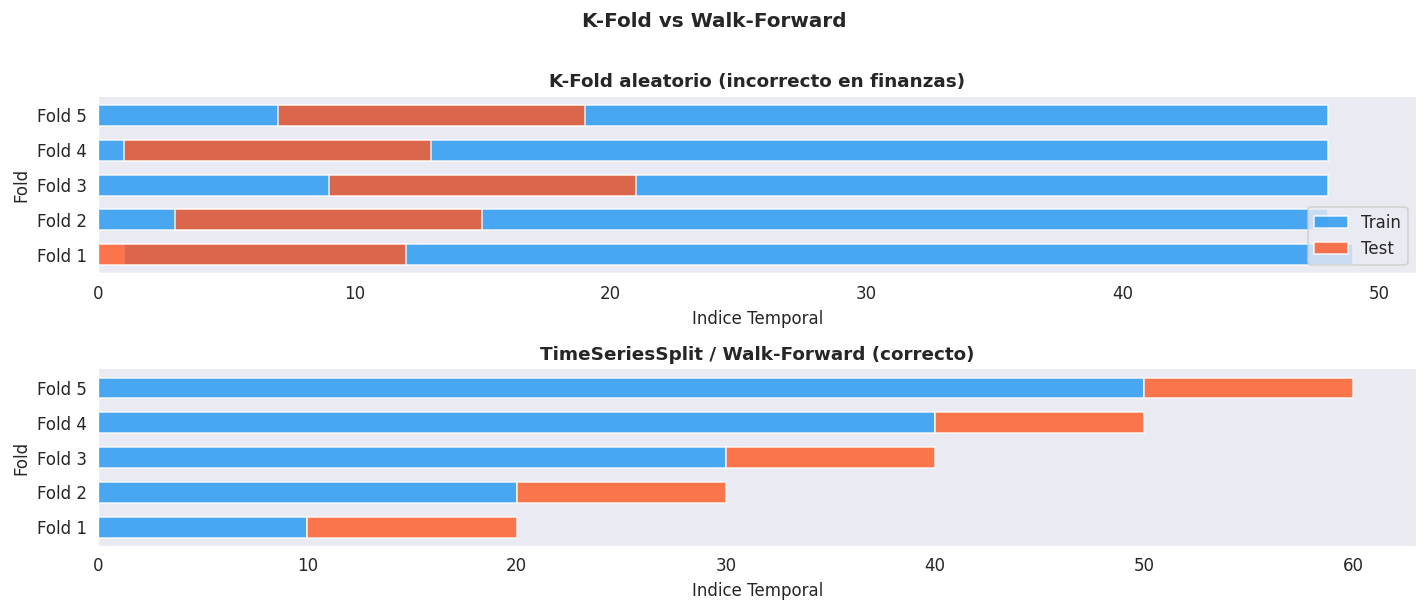

In [6]:
from sklearn.model_selection import KFold

n_samples = 60
n_splits  = 5
X_dummy   = np.arange(n_samples).reshape(-1, 1)

fig, axes = plt.subplots(2, 1, figsize=(12, 5))

splitters = [
    ('K-Fold aleatorio (incorrecto en finanzas)', KFold(n_splits = n_splits, shuffle = True, random_state = 42)),
    ('TimeSeriesSplit / Walk-Forward (correcto)',  TimeSeriesSplit(n_splits = n_splits)),
]

for ax, (title, splitter) in zip(axes, splitters):
    fold_map = np.full(n_samples, np.nan)
    for fold_i, (tr, te) in enumerate(splitter.split(X_dummy)):
        fold_map[tr] = 0   # train
        fold_map[te] = 1   # test
        ax.barh(fold_i, len(tr), left=tr[0], height=0.6, color = TRAIN_COLOR, alpha = 0.8, label = 'Train' if fold_i == 0 else '')
        ax.barh(fold_i, len(te), left=te[0], height=0.6, color = TEST_COLOR,  alpha = 0.8, label = 'Test'  if fold_i == 0 else '')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Indice Temporal')
    ax.set_ylabel('Fold')
    ax.set_yticks(range(n_splits))
    ax.set_yticklabels([f'Fold {i+1}' for i in range(n_splits)])

axes[0].legend(loc='lower right')
plt.suptitle('K-Fold vs Walk-Forward', fontsize = 12, fontweight='bold', y = 1.01)
plt.tight_layout()
plt.show()

### **Leakage Temporal**

<tr>
<td><img src="../figs/figura_009.png" align="middle" style="width: 1000px;"/> </td>
</tr>

**`Data leakage`** ocurre cuando información del conjunto de evaluación (validación o test) contamina el proceso de entrenamiento, produciendo una estimación del error optimistamente sesgada. Formalmente, esto es: Sea $\mathcal{D} = \{(x_t, y_t)\}_{t=1}^{T}$ una serie de observaciones ordenadas en el tiempo. Existe *leakage temporal* si el modelo entrenado en $\mathcal{D}_{train} = {t \leq \tau}$ utiliza, directa o indirectamente, información de $\mathcal{D}_{test} = {t > \tau}$ para algún $\tau < T$. Este, es el error más costoso en ML financiero ya que produce backtests brillantes que fallan en producción.

Algunos de los *Leakage* mas comunes:

#### Leakage 1. Normalizar con toda la serie antes del split

In [7]:
spy_ret = returns['SPY'].values.reshape(-1, 1)
split_idx = int(len(spy_ret) * 0.8)

In [8]:
spy_ret

array([[ 2.64754989e-03],
       [ 7.03975546e-04],
       [ 4.22133024e-03],
       ...,
       [ 6.65236580e-05],
       [-1.05264112e-02],
       [-1.14116086e-02]], shape=(3772, 1))

In [9]:
split_idx

3017

In [10]:
# Incorrecto:  EL Scaler ve los datos de test
scaler_bad = StandardScaler()
X_scaled_bad = scaler_bad.fit_transform(spy_ret)
X_train_bad, X_test_bad = X_scaled_bad[:split_idx], X_scaled_bad[split_idx:]

In [11]:
# Correcto: el Scaler solo ve los datos de train
scaler_good = StandardScaler()
X_train_good = scaler_good.fit_transform(spy_ret[:split_idx])
X_test_good  = scaler_good.transform(spy_ret[split_idx:]) 

Una forma mas elegante de hacer esto, y mas formal es utilizar `Pipelines`

📌 **`Pipeline`** es un objeto que encadena pasos de procesamiento en secuencia, garantizando que cada paso se ajusta solo con los datos de train y se aplica correctamente en test.

```python
spy = returns['SPY'].values.reshape(-1, 1)
split_idx = int(len(spy) * 0.8)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(C=0.1, max_iter=1000)),
])

X_train, X_test = spy[:split_idx], spy[split_idx:]
y_train, y_test = (spy[:split_idx] > 0).astype(int).ravel(), (spy[split_idx:] > 0).astype(int).ravel()

pipe.fit(X_train, y_train)
```

La particularidad que tiene `Pipeline` es que hace exactamente lo mismo que hicimos anteriormente, pero lo hace por dentro, eliminando el riesgo de equivocarse en el orden o de hacer fit accidentalmente en el test.

#### Leakage 2. Feature rolling centrada / mal alineada

In [12]:
df = returns[['SPY']].copy()

# Incorrecto: rolling centrado incluye t+1, t+2, ...
df['rolling_mean_bad'] = df['SPY'].rolling(window = 10, center = True).mean()
df

Ticker,SPY,rolling_mean_bad
Date,,
2010-01-05,0.002648,NaN
2010-01-06,0.000704,NaN
2010-01-07,0.004221,NaN
2010-01-08,0.003328,NaN
2010-01-11,0.001396,NaN
...,...,...
2024-12-23,0.005988,-0.002272
2024-12-24,0.011115,NaN
2024-12-26,0.000067,NaN


In [13]:
# Correcto: solo usa información disponible hasta t (ventana hacia atrás)
df['rolling_mean_good'] = df['SPY'].rolling(window = 10, center = False).mean()
df

Ticker,SPY,rolling_mean_bad,rolling_mean_good
Date,,,
2010-01-05,0.002648,NaN,NaN
2010-01-06,0.000704,NaN,NaN
2010-01-07,0.004221,NaN,NaN
2010-01-08,0.003328,NaN,NaN
2010-01-11,0.001396,NaN,NaN
...,...,...,...
2024-12-23,0.005988,-0.002272,-0.001269
2024-12-24,0.011115,NaN,0.000153
2024-12-26,0.000067,NaN,-0.000613


In [14]:
# Correcto: lag explícito — en t usas el rolling de t-1
df['rolling_mean_lagged'] = df['rolling_mean_good'].shift(1)
df

Ticker,SPY,rolling_mean_bad,rolling_mean_good,rolling_mean_lagged
Date,,,,
2010-01-05,0.002648,NaN,NaN,NaN
2010-01-06,0.000704,NaN,NaN,NaN
2010-01-07,0.004221,NaN,NaN,NaN
2010-01-08,0.003328,NaN,NaN,NaN
2010-01-11,0.001396,NaN,NaN,NaN
...,...,...,...,...
2024-12-23,0.005988,-0.002272,-0.001269,-0.002383
2024-12-24,0.011115,NaN,0.000153,-0.001269
2024-12-26,0.000067,NaN,-0.000613,0.000153


#### Leakage 3. Label leakage — no desplazar correctamente el target

In [15]:
df2 = returns[['SPY']].copy()
df2.columns = ['ret_t']

In [16]:
# Incorrecto: el label es el retorno en t (mismo momento que los features de t)
df2['label_bad'] = (df2['ret_t'] > 0).astype(int)   # predices r_t usando features de r_t 
df2

,ret_t,label_bad
Date,,
2010-01-05,0.002648,1
2010-01-06,0.000704,1
2010-01-07,0.004221,1
2010-01-08,0.003328,1
2010-01-11,0.001396,1
...,...,...
2024-12-23,0.005988,1
2024-12-24,0.011115,1
2024-12-26,0.000067,1


In [17]:
# Correcto: el label es el retorno FUTURO r_{t+1}
df2['label_good'] = (df2['ret_t'].shift(-1) > 0).astype(int)
df2

,ret_t,label_bad,label_good
Date,,,
2010-01-05,0.002648,1,1
2010-01-06,0.000704,1,1
2010-01-07,0.004221,1,1
2010-01-08,0.003328,1,1
2010-01-11,0.001396,1,0
...,...,...,...
2024-12-23,0.005988,1,1
2024-12-24,0.011115,1,1
2024-12-26,0.000067,1,0


In [18]:
# Feature: retorno de ayer
df2['feature_ret_lag1'] = df2['ret_t'].shift(1)
df2 = df2.dropna()
df2

,ret_t,label_bad,label_good,feature_ret_lag1
Date,,,,
2010-01-06,0.000704,1,1,0.002648
2010-01-07,0.004221,1,1,0.000704
2010-01-08,0.003328,1,1,0.004221
2010-01-11,0.001396,1,0,0.003328
2010-01-12,-0.009326,0,1,0.001396
...,...,...,...,...
2024-12-23,0.005988,1,1,0.012011
2024-12-24,0.011115,1,1,0.005988
2024-12-26,0.000067,1,0,0.011115



### Relacion entre Leakage y AUC

Comparamos el AUC de un mismo modelo con y sin leakage (K-Fold aleatorio vs. Walk-Forward).

In [19]:
def _rsi(ret: pd.Series, window: int = 14) -> pd.Series:
    delta = ret
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

In [20]:
def build_features(ret: pd.Series, horizonte: int = 1) -> pd.DataFrame:
    """Pipeline de features básicos, todos con shift correcto."""
    r = ret.copy()
    df = pd.DataFrame(index=r.index)
    for lag in [1, 2, 3, 5, 10]:
        df[f'ret_lag{lag}'] = r.shift(lag)
    for win in [5, 10, 20, 60]:
        df[f'rolling_mean_{win}'] = r.shift(1).rolling(win).mean()
        df[f'rolling_std_{win}']  = r.shift(1).rolling(win).std()
    df[f'rolling_skew_20'] = r.shift(1).rolling(20).skew()
    df['rsi_14'] = _rsi(r.shift(1), 14)
    df['label']  = (r.shift(-horizonte) > 0).astype(int)
    return df.dropna()

In [21]:
feat = build_features(returns['SPY'])
X = feat.drop(columns = ['label'])
y = feat['label']

print(f'Dataset: {X.shape[0]} observaciones, {X.shape[1]} features')
print(f'Periodo: {X.index[0].date()} - {X.index[-1].date()}')
print(f'Balance de clases: {y.mean():.2%} días alcistas')

Dataset: 3712 observaciones, 15 features
Periodo: 2010-04-01 - 2024-12-30
Balance de clases: 55.12% días alcistas


In [22]:
#  Pipeline anti-leakage 
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, C=0.1)),
])

In [23]:
# K-Fold aleatorio (incorrecto)
kf_scores = cross_val_score(
    pipe, X, y,
    cv=KFold(n_splits = 10, shuffle = True, random_state = 42),
    scoring = 'roc_auc'
)

In [24]:
# TimeSeriesSplit (correcto)
tss_scores = cross_val_score(
    pipe, X, y,
    cv = TimeSeriesSplit(n_splits = 10),
    scoring = 'roc_auc'
)

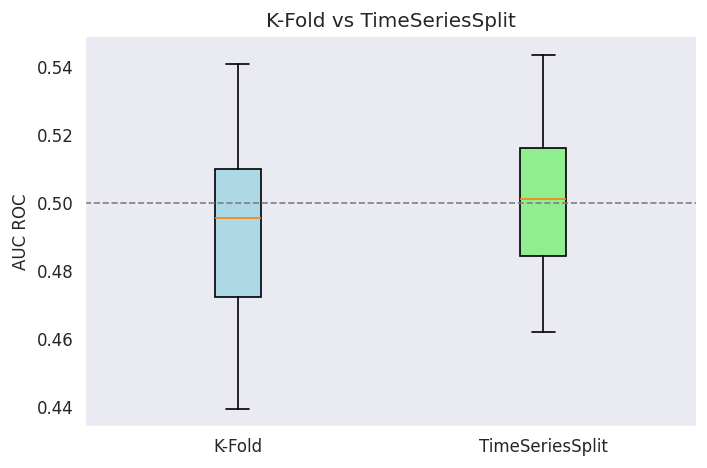

In [25]:

fig, ax = plt.subplots(figsize = (6, 4))
bp = ax.boxplot([kf_scores, tss_scores], labels = ['K-Fold', 'TimeSeriesSplit'], patch_artist = True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')
ax.axhline(0.5, ls ='--', color = 'gray', lw = 1)
ax.set_ylabel('AUC ROC')
ax.set_title('K-Fold vs TimeSeriesSplit')
plt.tight_layout()
plt.show()


## 🔮 **`Splits Temporales Básicos`**

### **Holdout Temporal Simple**

Bloque de observaciones que pertenece a un periodo estrictamente futuro respecto al train, reservado exclusivamente para el reporte final de desempeño. No interviene en ninguna decisión de modelamiento.

Dado un dataset ordenado $\{(x_t, y_t)\}_{t=1}^{T}$ y un punto de corte $\tau$:

\begin{equation*}
\mathcal{D}_{train} = {t \leq \tau_1} \qquad \mathcal{D}_{dev} = {\tau_1 < t \leq \tau_2} \qquad \mathcal{D}_{oot} = {t > \tau_2}
\end{equation*}

<tr>
<td><img src="../figs/figura_010.png" align="middle" style="width: 1000px;"/> </td>
</tr>

Algunas consideraciones de este enfoque:

* El problema del **`Holdout Simple`** es que entrega una sola estimación del desempeño. No se sabe si ese periodo fue fácil o difícil, ni si el modelo se degrada con el tiempo. Para responder esa pregunta existe el **`Walk-Forward Validation`**, que en lugar de hacer un único corte, hace múltiples cortes sucesivos a lo largo del tiempo, generando una distribución de métricas fold a fold. Así puedes ver si el modelo es estable o si su desempeño cambia según el periodo.

* Dentro del **`Walk-Forward`**, la pregunta que surge es cómo debe crecer el train en cada fold. Aquí aparecen **`Expanding Window`** y **`Rolling Window`** como dos respuestas distintas a esa pregunta. 
  
* La **`Expanding Window`** acumula toda la historia disponible en cada fold — el train del fold 2 incluye todo lo que había en el fold 1 más el periodo nuevo.

    <tr>
    <td><img src="../figs/figura_011.png" align="middle" style="width: 1000px;"/> </td>
    </tr>

* **`Rolling Window`** en cambio mantiene un tamaño fijo de train, desplazándose hacia adelante y descartando las observaciones más antiguas. La primera asume que toda la historia es útil; la segunda asume que el pasado lejano ya no es relevante porque el mercado ha cambiado

    <tr>
    <td><img src="../figs/figura_012.png" align="middle" style="width: 1000px;"/> </td>
    </tr>


En resumen, Holdout Temporal define el marco general de evaluación final. El Walk-Forward es la estrategia de validación durante el desarrollo del modelo. Y Expanding y Rolling son las dos formas de construir el train dentro de ese Walk-Forward.


## 🚚 **`Gap`**

### ¿Por qué existe el gap?

Si un feature usa una rolling window de $L$ días y predices con horizonte $h$, las últimas $L$ observaciones del train y las primeras del test **comparten información**: el feature de test usa precios que también están en el train.

\begin{equation*}
\text{Gap mínimo} = \max(L, h)
\end{equation*}

En la práctica, para evitar solapamiento entre rolling features del train y el test:
- Si `rolling_window = 20` días y `horizonte = 1`: gap ≥ 1 (solo evitar el label)
- Si `rolling_window = 60` días y `horizonte = 5`: gap = 60 (evitar solapamiento de features)

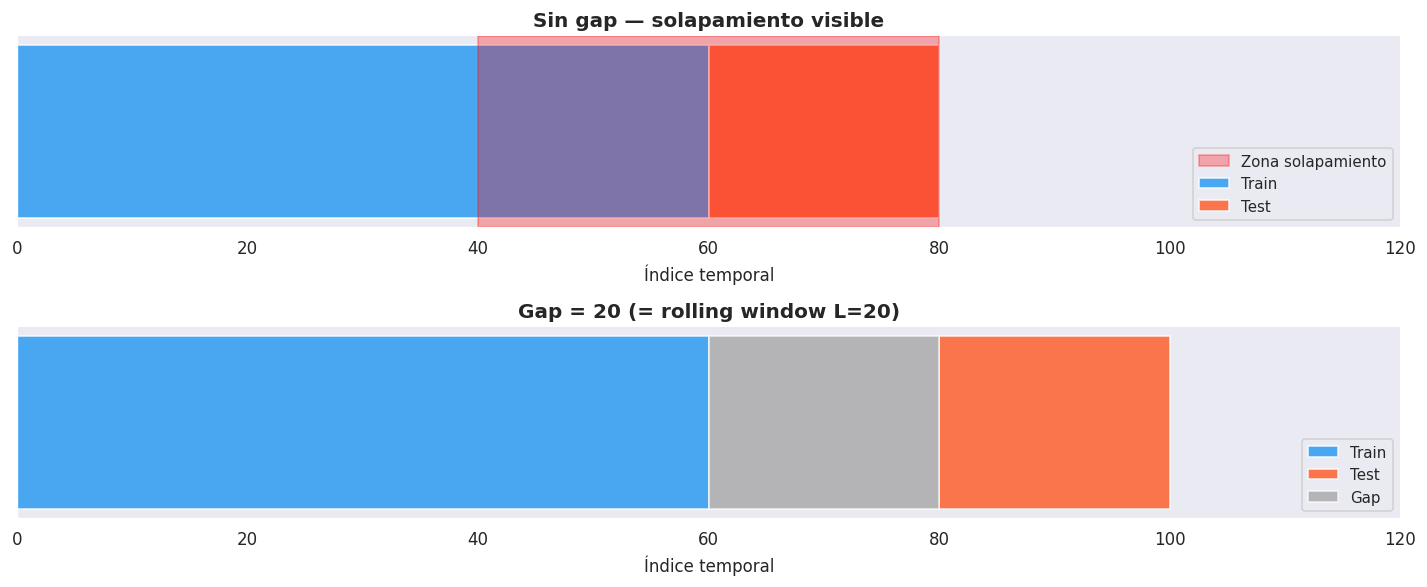

In [26]:
n_obs      = 120
train_size = 60
test_size  = 20
rolling_L  = 20   # ventana de feature rolling
horizonte  = 5    # horizonte de predicción
gap_real   = rolling_L  # gap conservador

fig, axes = plt.subplots(2, 1, figsize=(12, 5))

scenarios = [
    (0,        'Sin gap — solapamiento visible'),
    (gap_real, f'Gap = {gap_real} (= rolling window L=20)'),
]

for ax, (gap, label) in zip(axes, scenarios):
    tr = np.arange(0, train_size)
    te = np.arange(train_size + gap, train_size + gap + test_size)
    g  = (train_size, train_size + gap)

    ax.barh(0, len(tr), left=0,              height=0.5, color=TRAIN_COLOR, alpha=0.8, label='Train')
    ax.barh(0, len(te), left=te.min(),       height=0.5, color=TEST_COLOR,  alpha=0.8, label='Test')
    if gap > 0:
        ax.barh(0, gap, left=train_size,     height=0.5, color=GAP_COLOR,   alpha=0.7, label='Gap')

    # Zona de solapamiento rolling
    overlap_start = max(0, train_size - rolling_L)
    overlap_end   = train_size + gap if gap > 0 else train_size + rolling_L
    if gap == 0:
        ax.axvspan(overlap_start, min(train_size + rolling_L, n_obs),
                   alpha=0.3, color='red', label='Zona solapamiento')

    ax.set_xlim(0, n_obs)
    ax.set_yticks([])
    ax.set_xlabel('Índice temporal')
    ax.set_title(label, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## 🔫 **`Walk-Forward`**

### Idea Central

El Walk-Forward replica la forma en que un modelo opera en producción. En el mundo real, un modelo se entrena con historia disponible hasta hoy, genera predicciones para mañana, y luego se re-entrena incorporando los nuevos datos. Walk-Forward simula exactamente ese proceso: entrena, predice, avanza, re-entrena, predice, avanza — y así sucesivamente a lo largo de toda la serie.

### ¿Por qué es necesario?

El holdout simple entrega una sola métrica. Esa métrica puede ser engañosa porque depende completamente del periodo elegido como test. Si ese periodo fue excepcionalmente tranquilo o excepcionalmente volátil, la métrica no representa el desempeño real del modelo. Walk-Forward resuelve esto generando una distribución de métricas a través del tiempo, lo que permite responder no solo "qué tan bueno es el modelo" sino "qué tan estable es".

### ¿Cómo funciona?

Se define un tamaño mínimo inicial de train y un tamaño de bloque de test. El algoritmo parte entrenando con los primeros $n$ datos y evalúa en el bloque siguiente. Luego avanza un paso hacia adelante — incorporando ese bloque al train — y vuelve a evaluar en el siguiente bloque. Este ciclo se repite hasta cubrir toda la serie.

En cada iteración se obtiene una métrica: AUC, Sharpe, accuracy. Al final no tienes un número sino una serie de números, uno por fold, que puedes analizar como distribución. Un modelo robusto tendrá métricas estables a lo largo de los folds. Un modelo frágil mostrará alta varianza o degradación sistemática hacia los folds más recientes.

### Concepto de GAP

Entre el último dato de train y el primer dato de test existe un riesgo de contaminación cuando los features usan ventanas rolling. Si el feature de hoy usa los últimos 20 días, y el train termina hoy, entonces los primeros días del test comparten información con el train a través de esa ventana. Para evitarlo se introduce un gap — un bloque de observaciones que se descarta entre train y test, cuyo tamaño mínimo es igual al tamaño de la ventana rolling más larga usada en los features.

Al tener métricas fold a fold puedes detectar tres patrones críticos. 

* Degradación Temporal: el modelo funciona bien en folds antiguos pero se deteriora en los más recientes, señal de que el mercado cambió y el modelo no generalizó. 
  
* Inestabilidad: las métricas saltan erráticamente entre folds, señal de que el modelo es sensible al periodo y no es confiable. 
  
* Overfitting in-sample: el modelo muestra AUC alto en train y bajo en test en casi todos los folds, señal de que memorizó patrones que no generalizan.


### Algoritmo y Diseño

```
Parámetros:
  train_start    : inicio del primer bloque de entrenamiento
  initial_train  : tamaño mínimo del train
  test_size      : tamaño de cada bloque de test
  step           : cuánto avanza la ventana por fold
  gap            : observaciones entre fin de train y comienzo de test
  window         : 'expanding' | 'rolling' (tamaño fijo)

Por fold i:
  1. Definir [train_start, train_end]
  2. Predecir en [train_end + gap + 1, train_end + gap + test_size]
  3. Calcular métricas del fold
  4. Avanzar step posiciones y repetir
```

| Decisión | Demasiado chico | Demasiado grande |
|----------|-----------------|------------------|
| `initial_train` | Alta varianza, estimaciones inestables | Incorpora regímenes muy viejos |
| `test_size` | Métricas por fold muy ruidosas | Pocos folds, poca cobertura temporal |
| `gap` | Riesgo de solapamiento | Pierde datos útiles en la frontera |
| `step` | Muchos folds, cómputo costoso | Saltos grandes, baja resolución temporal |

Fold   1 | Train: 504 obs | Test inicio: 2012-01 | AUC: 0.4604
Fold   2 | Train: 525 obs | Test inicio: 2012-02 | AUC: 0.4224
Fold   3 | Train: 546 obs | Test inicio: 2012-03 | AUC: 0.4765
Fold   4 | Train: 567 obs | Test inicio: 2012-04 | AUC: 0.5867
Fold   5 | Train: 588 obs | Test inicio: 2012-05 | AUC: 0.6085
Fold   6 | Train: 609 obs | Test inicio: 2012-06 | AUC: 0.5095
Fold   7 | Train: 630 obs | Test inicio: 2012-07 | AUC: 0.4605
Fold   8 | Train: 651 obs | Test inicio: 2012-08 | AUC: 0.4102
Fold   9 | Train: 672 obs | Test inicio: 2012-09 | AUC: 0.4071
Fold  10 | Train: 693 obs | Test inicio: 2012-10 | AUC: 0.3879
Fold  11 | Train: 714 obs | Test inicio: 2012-11 | AUC: 0.4522
Fold  12 | Train: 735 obs | Test inicio: 2012-12 | AUC: 0.4856
Fold  13 | Train: 756 obs | Test inicio: 2013-01 | AUC: 0.6263
Fold  14 | Train: 777 obs | Test inicio: 2013-02 | AUC: 0.5435
Fold  15 | Train: 798 obs | Test inicio: 2013-03 | AUC: 0.5864
Fold  16 | Train: 819 obs | Test inicio: 2013-04 | AUC:

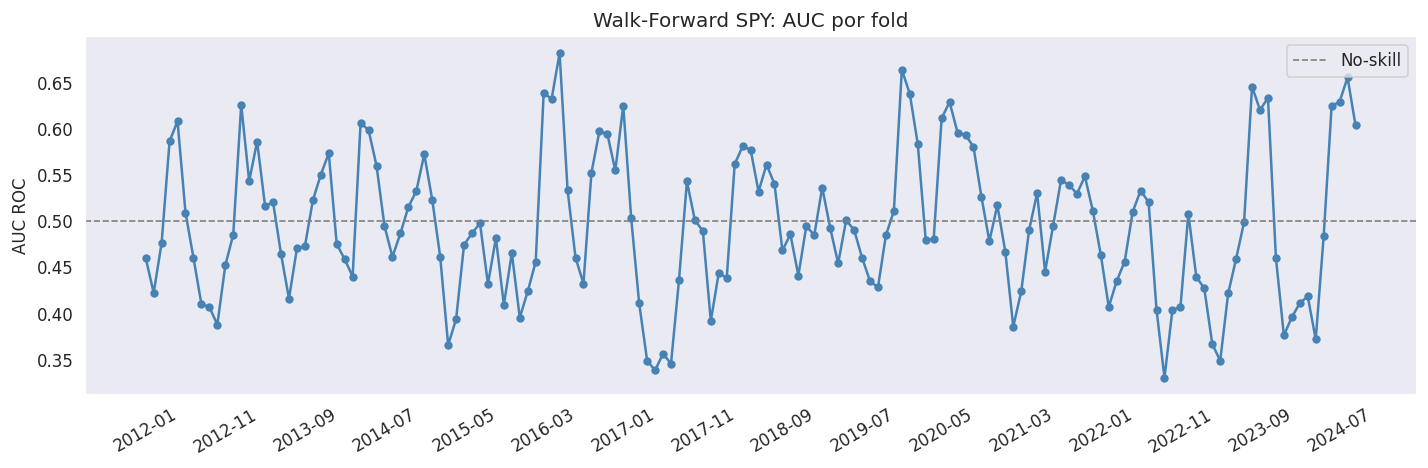

In [27]:


# Serie de Retornos 
spy = returns['SPY'].dropna()
X   = spy.shift(1).to_frame('ret_lag1').dropna()
y   = (spy.shift(-1) > 0).astype(int).reindex(X.index).dropna()
X, y = X.align(y, join='inner', axis=0)

# Parametros Walk-Forward 
initial_train = 504   # ~2 años
test_size     = 63    # ~1 trimestre
step          = 21    # avanza 1 mes
gap = 5 

# Walk-Forward 
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(C=0.1, max_iter=1000)),
])

end     = initial_train
results = []

while end + gap + test_size <= len(X):
    X_tr, y_tr = X.iloc[:end], y.iloc[:end]
    X_te, y_te = X.iloc[end + gap:end + gap + test_size], y.iloc[end + gap:end + gap + test_size]

    pipe.fit(X_tr, y_tr)
    auc = roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1])

    results.append({
        'fold':       len(results) + 1,
        'test_start': X_te.index[0].strftime('%Y-%m'),
        'n_train':    len(X_tr),
        'auc':        auc,
    })

    print(f"Fold {results[-1]['fold']:>3} | Train: {len(X_tr)} obs | Test inicio: {results[-1]['test_start']} | AUC: {auc:.4f}")
    end += step

# Reporte
aucs = [r['auc'] for r in results]
print(f"\nAUC media : {np.mean(aucs):.4f}")
print(f"AUC std   : {np.std(aucs):.4f}")
print(f"Folds > 0.5: {sum(a > 0.5 for a in aucs)}/{len(aucs)}")

# Visualización 
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot([r['test_start'] for r in results], aucs, marker='o', ms=4, color='steelblue')
ax.axhline(0.5, ls='--', color='gray', lw=1, label='No-skill')
ax.set_xticks(range(0, len(results), 10))
ax.set_xticklabels([results[i]['test_start'] for i in range(0, len(results), 10)], rotation=30)
ax.set_ylabel('AUC ROC')
ax.set_title('Walk-Forward SPY: AUC por fold')
ax.legend()
plt.tight_layout()
plt.show()


## 🧨 **`Nested CV Temporal`**

### El problema

Cuando se entrena un modelo, normalmente se busca los mejores hiperparámetros evaluándolos en algún conjunto de validación. El problema surge cuando ese conjunto de validación es el mismo que usas para reportar el desempeño final. En ese caso, sin darse cuenta, se está eligiendo el modelo que mejor funciona en el test — y eso es otra forma de leakage. El modelo que reportas no es el que tendrías en producción, porque fue seleccionado mirando datos que no debería haber visto.

Nested CV resuelve esto separando en dos loops independientes: uno externo que estima el desempeño real, y uno interno que elige los hiperparámetros. El loop externo nunca participa en la selección de hiperparámetros, y el loop interno nunca ve el test del loop externo.

<tr>
<td><img src="../figs/figura_013.png" align="middle" style="width: 1000px;"/> </td>
</tr>

In [28]:
# Datos 
spy = returns['SPY'].dropna()
X   = spy.shift(1).to_frame('ret_lag1').dropna()
y   = (spy.shift(-1) > 0).astype(int).reindex(X.index).dropna()
X, y = X.align(y, join='inner', axis=0)

In [29]:
# Parametros
initial_train = 504
test_size     = 63
step          = 21
gap           = 5

In [30]:
# Pipeline 
pipe      = Pipeline(
    [('scaler', StandardScaler()), 
     ('model', LogisticRegression(max_iter = 1000))])

param_grid = {'model__C': [0.01, 0.1, 1.0, 10.0]}

In [31]:
# Nested CV Walk-Forward
end     = initial_train
results = []

while end + gap + test_size <= len(X):
    X_tr = X.iloc[:end]
    y_tr = y.iloc[:end]
    X_te = X.iloc[end + gap : end + gap + test_size]
    y_te = y.iloc[end + gap : end + gap + test_size]

    # Loop interno: tuning SOLO sobre X_tr
    gs = GridSearchCV(clone(pipe), param_grid, cv=TimeSeriesSplit(n_splits=3), scoring='roc_auc')
    gs.fit(X_tr, y_tr)

    # Evaluación outer: test nunca visto en el tuning
    auc_outer = roc_auc_score(y_te, gs.predict_proba(X_te)[:, 1])

    results.append({
        'fold':       len(results) + 1,
        'test_start': X_te.index[0].strftime('%Y-%m'),
        'n_train':    len(X_tr),
        'best_C':     gs.best_params_['model__C'],
        'inner_auc':  gs.best_score_,
        'outer_auc':  auc_outer,
    })

    print(f"Fold {results[-1]['fold']:>3} | "
          f"Train: {len(X_tr):>4} obs | "
          f"best_C: {gs.best_params_['model__C']:>5} | "
          f"AUC inner: {gs.best_score_:.4f} | "
          f"AUC outer: {auc_outer:.4f}")

    end += step

df = pd.DataFrame(results).set_index('fold')
df['brecha'] = df.inner_auc - df.outer_auc

Fold   1 | Train:  504 obs | best_C:  0.01 | AUC inner: 0.5156 | AUC outer: 0.4604
Fold   2 | Train:  525 obs | best_C:  0.01 | AUC inner: 0.5145 | AUC outer: 0.4224
Fold   3 | Train:  546 obs | best_C:  0.01 | AUC inner: 0.5152 | AUC outer: 0.4765
Fold   4 | Train:  567 obs | best_C:  0.01 | AUC inner: 0.5123 | AUC outer: 0.5867
Fold   5 | Train:  588 obs | best_C:  0.01 | AUC inner: 0.5010 | AUC outer: 0.6085
Fold   6 | Train:  609 obs | best_C:  0.01 | AUC inner: 0.5009 | AUC outer: 0.5095
Fold   7 | Train:  630 obs | best_C:  0.01 | AUC inner: 0.5055 | AUC outer: 0.4605
Fold   8 | Train:  651 obs | best_C:  0.01 | AUC inner: 0.5054 | AUC outer: 0.4102
Fold   9 | Train:  672 obs | best_C:  0.01 | AUC inner: 0.5092 | AUC outer: 0.4071
Fold  10 | Train:  693 obs | best_C:  0.01 | AUC inner: 0.5032 | AUC outer: 0.3879
Fold  11 | Train:  714 obs | best_C:  0.01 | AUC inner: 0.5052 | AUC outer: 0.4522
Fold  12 | Train:  735 obs | best_C:  0.01 | AUC inner: 0.4918 | AUC outer: 0.4856
Fold

In [32]:
# Reporte 
print(f"\n{'='*55}")
print(f"{'Métrica':<25} {'Inner':>10} {'Outer':>10}")
print(f"{'='*55}")
print(f"{'AUC media':<25} {df.inner_auc.mean():>10.4f} {df.outer_auc.mean():>10.4f}")
print(f"{'AUC std':<25} {df.inner_auc.std():>10.4f} {df.outer_auc.std():>10.4f}")
print(f"{'Brecha media (I-O)':<25} {df.brecha.mean():>10.4f}")
print(f"{'Folds outer > 0.5':<25} {(df.outer_auc > 0.5).mean():>10.0%}")
print(f"{'='*55}")


Métrica                        Inner      Outer
AUC media                     0.5027     0.4951
AUC std                       0.0055     0.0787
Brecha media (I-O)            0.0075
Folds outer > 0.5                43%


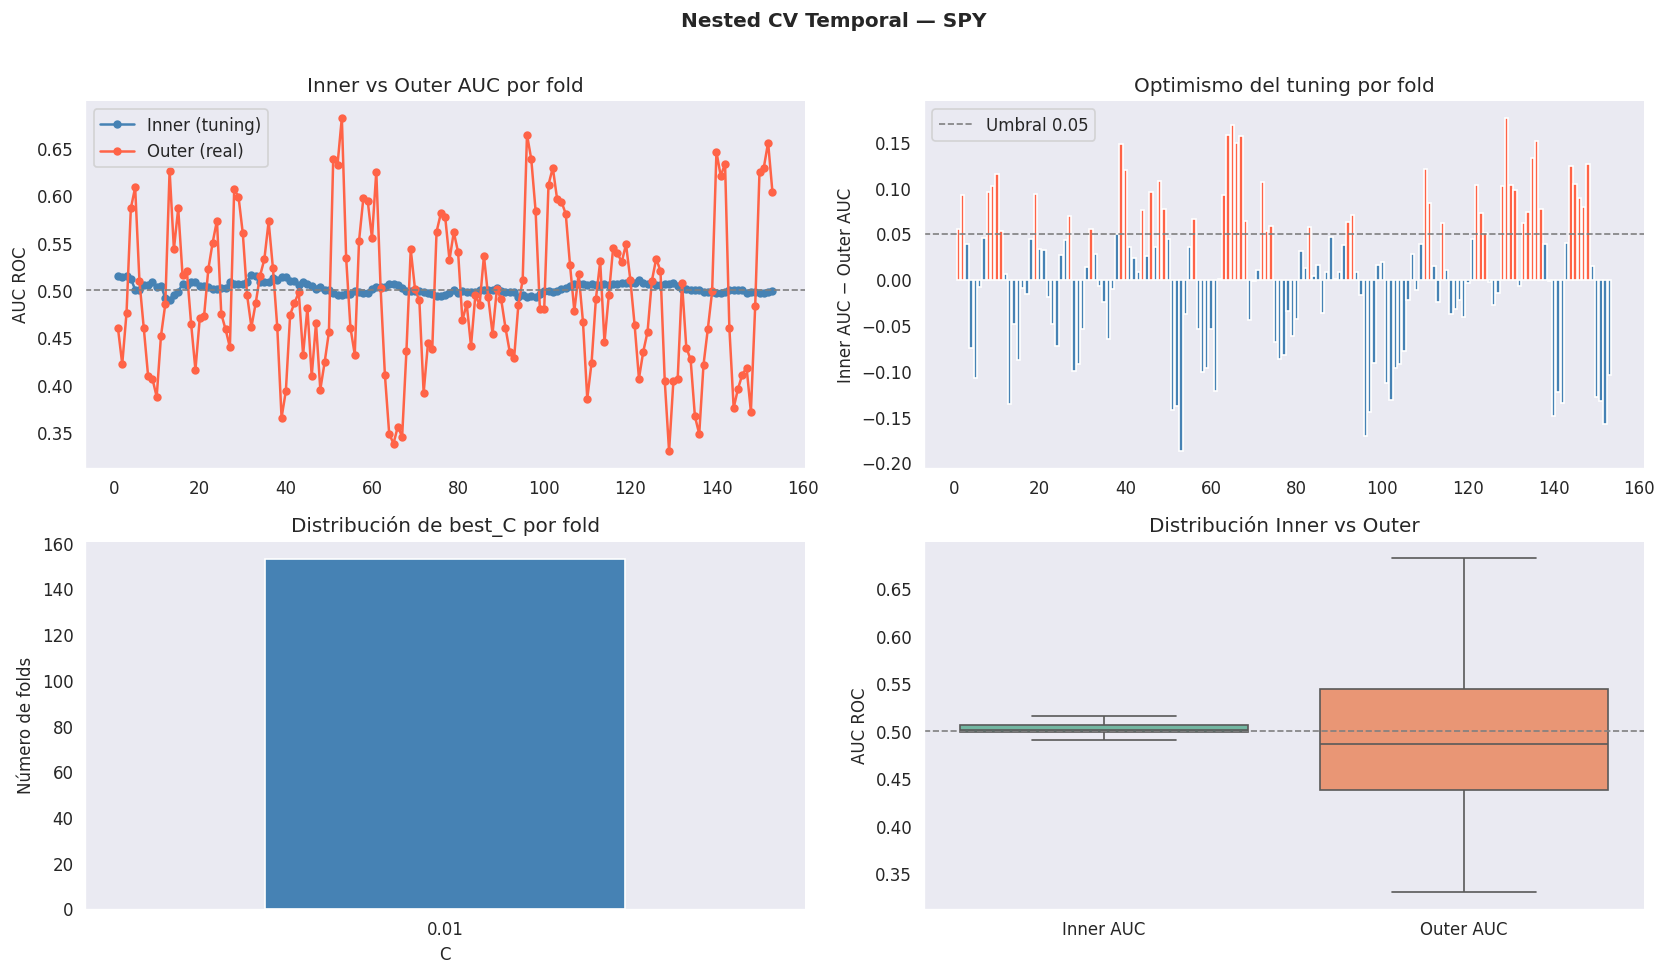

In [33]:
# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
folds = df.index

# Inner vs Outer por fold
ax = axes[0, 0]
ax.plot(folds, df.inner_auc, marker='o', ms=4, label='Inner (tuning)', color='steelblue')
ax.plot(folds, df.outer_auc, marker='o', ms=4, label='Outer (real)',   color='tomato')
ax.axhline(0.5, ls='--', color='gray', lw=1)
ax.set_ylabel('AUC ROC')
ax.set_title('Inner vs Outer AUC por fold')
ax.legend()

# Brecha inner - outer por fold
ax = axes[0, 1]
ax.bar(folds, df.brecha, color=['tomato' if b > 0.05 else 'steelblue' for b in df.brecha])
ax.axhline(0.05, ls='--', color='gray', lw=1, label='Umbral 0.05')
ax.set_ylabel('Inner AUC − Outer AUC')
ax.set_title('Optimismo del tuning por fold')
ax.legend()

# Distribución de best_C
ax = axes[1, 0]
df.best_C.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('C')
ax.set_ylabel('Número de folds')
ax.set_title('Distribución de best_C por fold')
ax.tick_params(axis='x', rotation=0)

# Boxplot inner vs outer
ax = axes[1, 1]
sns.boxplot(data=[df.inner_auc, df.outer_auc], palette='Set2', ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Inner AUC', 'Outer AUC'])
ax.axhline(0.5, ls='--', color='gray', lw=1)
ax.set_ylabel('AUC ROC')
ax.set_title('Distribución Inner vs Outer')

plt.suptitle('Nested CV Temporal — SPY', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
